## PRINCIPAL COMPONENT ANALYSIS

**Implementing PCA from scratch**

**STEPS**

1. Subtract the mean from X --> Do standardisation to avoid the bias
2. Calculate CoV(X,Y) --> calculate the covariance matrix
3. Calculate the eigenvectors and eigen values
4. sort the eigenvectors according to their eigen values in decending order
5. Choose first k eigen vectors and that will be the new k dimensions
6. Transform the original n-dimensional data points into k dimensions (Projects with dot product)

In [7]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 100
age = np.random.normal(40, 10, n_samples)
experience = age * 0.8 + np.random.normal(0, 2, n_samples) 
salary = experience * 5 + np.random.normal(0, 5, n_samples) 
savings = salary * 0.2 + np.random.normal(0, 10, n_samples)
fitness_score = np.random.normal(50, 15, n_samples)          

data_matrix = np.column_stack([age, experience, salary, savings, fitness_score])
columns = ['Age', 'Experience', 'Salary', 'Savings', 'Fitness']
df = pd.DataFrame(data_matrix, columns=columns)

print("Original 5D Data (First 5 rows):")
print(df.head())

Original 5D Data (First 5 rows):
         Age  Experience      Salary    Savings    Fitness
0  44.967142   33.142972  167.503796  25.210809  26.083585
1  38.617357   30.052595  153.066897  25.011569  41.009375
2  46.476885   36.496079  187.895653  45.052067  50.078655
3  55.230299   42.579684  218.167432  49.737189  50.704709
4  37.658466   29.804202  142.132661  28.217516  43.249018


**STEP-1**

Standardisation - PCA is all about variance. If one variable is measured in "kilometers" and another in "millimeters," the millimeter variable will have a huge variance just because of the units. Standardizing (Z-score normalization) puts everything on a level playing field.

In [8]:
X = df.values
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

print("Standardized Data (Mean = 0, Std = 1):\n", X_std)

Standardized Data (Mean = 0, Std = 1):
 [[ 6.64619211e-01  2.67225331e-01  2.96648861e-01 -6.76601691e-01
  -1.45353897e+00]
 [-3.80889416e-02 -1.60856212e-01 -8.88272544e-02 -6.95491814e-01
  -5.13389476e-01]
 [ 8.31697213e-01  7.31700553e-01  8.41126891e-01  1.20456648e+00
   5.78687341e-02]
 [ 1.80040643e+00  1.57440654e+00  1.64940633e+00  1.64876732e+00
   9.73027485e-02]
 [-1.44205981e-01 -1.95263866e-01 -3.80779646e-01 -3.91532964e-01
  -3.72318246e-01]
 [-1.44187812e-01 -3.86238970e-02 -1.71092082e-01 -1.11562097e-01
   6.41397854e-01]
 [ 1.86258212e+00  2.38148289e+00  2.35532405e+00  2.78276010e+00
  -9.55798920e-01]
 [ 9.64216079e-01  1.00771080e+00  1.03114135e+00  7.01194203e-02
  -8.16091768e-02]
 [-4.04627405e-01 -3.40003706e-01 -2.67592309e-01  2.27374891e-01
   1.66572547e-01]
 [ 7.15355233e-01  6.89522242e-01  1.17023902e+00  5.38076609e-01
   5.38968459e-01]
 [-3.97924677e-01 -9.36223610e-01 -8.34762702e-01 -9.00508568e-01
   7.25265095e-01]
 [-4.00483353e-01 -4.1455

**STEP-2**

Calculate the covariance Matrix - We need to know how the features move together. The diagonal shows the variance of each feature, and the off-diagonals show how much "Feature A" tells us about "Feature B."

In [ ]:
# rowvar=False because features are in columns
cov_matrix = np.cov(X_std, rowvar=False)

print("Covariance Matrix Shape:", cov_matrix.shape)

Covariance Matrix Shape: (5, 5)


**STEP-3**

Eigen decomposition - We are looking for the "axes" (Eigenvectors) that capture the most spread in the data. The Eigenvalues tell us the "strength" of each axis.

In [10]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues (Variance magnitude):", eigenvalues)
print("Eigenvectors (Principal Directions):\n", eigenvectors)

Eigenvalues (Variance magnitude): [3.37861549 1.06953094 0.54598659 0.0470258  0.00934624]
Eigenvectors (Principal Directions):
 [[-0.52945456 -0.08096993 -0.21402685 -0.81032118  0.103411  ]
 [-0.5359025  -0.03028289 -0.2297761   0.31857266 -0.74673011]
 [-0.53631886 -0.03642298 -0.19857246  0.49031295  0.65665641]
 [-0.3765238   0.34637833  0.85889796 -0.01743781 -0.01555947]
 [ 0.05548229  0.93339286 -0.35250352 -0.03435382  0.01614205]]


**STEP-4, 5**

Sorting and selecting k - The linalg.eig function doesn't always return values in order. We sort them from highest to lowest because the highest eigenvalue represents the Principal Component 1.

In [11]:
k = 2

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

total_variance = np.sum(eigenvalues)
var_exp = [(i / total_variance) * 100 for i in eigenvalues]
cum_var_exp = np.cumsum(var_exp)

print("Variance Explained by each Component:", np.round(var_exp, 2))
print("Cumulative Variance Explained:", np.round(cum_var_exp, 2))

# Select the top k eigenvectors (Feature Vector)
projection_matrix = eigenvectors[:, :k]

print("Top k Eigenvectors (Projection Matrix):\n", projection_matrix)

Variance Explained by each Component: [66.9  21.18 10.81  0.93  0.19]
Cumulative Variance Explained: [ 66.9   88.07  98.88  99.81 100.  ]
Top k Eigenvectors (Projection Matrix):
 [[-0.52945456 -0.08096993]
 [-0.5359025  -0.03028289]
 [-0.53631886 -0.03642298]
 [-0.3765238   0.34637833]
 [ 0.05548229  0.93339286]]


**STEP-6**

Projection - This is the final "squashing" step. We take our original standardized data and multiply it by our projection matrix to move it into the new, lower-dimensional space.

In [ ]:
X_pca = np.dot(X_std, projection_matrix)

print("Final Reduced Data (PCA):\n", X_pca)
print("\nOriginal Shape:", X.shape)
print("New Shape:", X_pca.shape)

Final Reduced Data (PCA):
 [[-4.80079811e-01 -1.66379443e+00]
 [ 3.87394538e-01 -7.08906763e-01]
 [-1.73391552e+00  3.51113168e-01]
 [-3.29697108e+00  4.08386299e-01]
 [ 5.11976624e-01 -4.51679095e-01]
 [ 2.66391457e-01  5.79109690e-01]
 [-4.62640527e+00 -2.36967349e-01]
 [-1.63449339e+00 -1.98031725e-01]
 [ 4.63585233e-01  2.87040821e-01]
 [-1.54858149e+00  5.68020806e-01]
 [ 1.53940887e+00  4.56016645e-01]
 [ 2.30303296e-01 -6.25459734e-01]
 [-1.14799966e+00 -1.00606167e+00]
 [ 2.55646291e+00  1.35861734e+00]
 [ 3.01524160e+00  5.52072915e-01]
 [ 7.52875269e-01 -6.52327812e-01]
 [ 1.84221361e+00  1.48856185e+00]
 [-2.29475780e-01 -8.58470193e-03]
 [ 1.27846176e+00  1.11773028e+00]
 [ 2.49123602e+00 -6.54182337e-02]
 [-3.60495118e+00  2.12100455e+00]
 [ 7.14731279e-01  1.64712836e+00]
 [-5.97056330e-01 -3.73664641e-01]
 [ 2.73437312e+00  1.31063666e+00]
 [ 1.18456993e+00  2.20565115e-01]
 [-7.88532625e-01  9.75942545e-01]
 [ 2.07914473e+00 -6.09923743e-01]
 [-8.46670323e-01  8.6761565

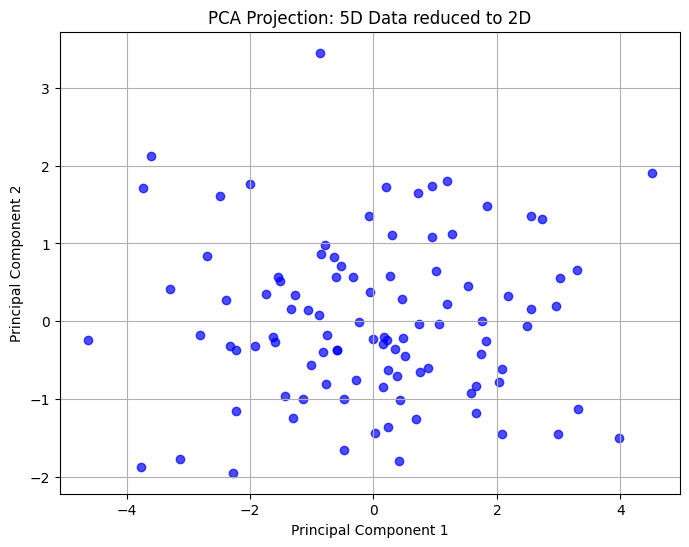

In [14]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.7, c='blue')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection: 5D Data reduced to 2D')
plt.grid(True)
plt.show()

Feature Loadings for PC1 and PC2:
                 PC1       PC2
Age        -0.529455 -0.080970
Experience -0.535902 -0.030283
Salary     -0.536319 -0.036423
Savings    -0.376524  0.346378
Fitness     0.055482  0.933393


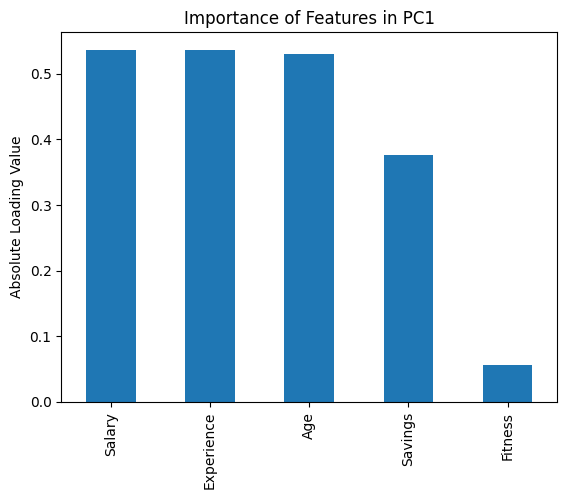

In [ ]:
loadings = pd.DataFrame(
    projection_matrix, 
    columns=['PC1', 'PC2'], 
    index=columns
)

print("Feature Loadings for PC1 and PC2:")
print(loadings)

loadings['PC1'].abs().sort_values(ascending=False).plot(kind='bar')
plt.title('Importance of Features in PC1')
plt.ylabel('Absolute Loading Value')
plt.show()